# Loan Amount Prediction using Machine Learning

**Problem type:** Supervised Machine Learning — Regression  
**Target variable:** `loan_amount`  
**Dataset:** `loan_amount_prediction_dataset.csv`  
**Dataset size:** 10,000 observations  
**Models:** Linear Regression and Random Forest Regressor

---

## Project Objective

The objective of this project is to predict the **loan amount** using customer-level financial and demographic variables. The workflow covers data understanding, data-quality checks, exploratory data analysis, model training, evaluation, residual analysis, feature importance, and final model selection.

> **Source integrity note:** This notebook reorganizes the completed Colab project into a GitHub-ready report format. The methodology, model configuration, reported metrics, feature relationships, and reported predictions are preserved from the supplied project source.


## Dataset Overview

The completed project uses **10,000 rows** and **14 input features** to predict `loan_amount`.

### Input Features

| # | Feature |
|---:|---|
| 1 | `age` |
| 2 | `monthly_income` |
| 3 | `annual_income` |
| 4 | `employment_years` |
| 5 | `credit_score` |
| 6 | `monthly_expenses` |
| 7 | `existing_loan_amount` |
| 8 | `existing_emi` |
| 9 | `savings` |
| 10 | `assets_value` |
| 11 | `loan_term_months` |
| 12 | `interest_rate` |
| 13 | `debt_to_income` |
| 14 | `dependents` |

The target variable is `loan_amount`.


## Import Libraries

The project uses standard Python data-analysis and machine-learning libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)


## Load Dataset

Upload `loan_amount_prediction_dataset.csv` in Google Colab, then load it into a pandas DataFrame.

The original project used the same filename and did not include a separate preprocessing/model pipeline file.


In [ ]:
# Google Colab upload
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("loan_amount_prediction_dataset.csv")
df.head()


## Basic Data Understanding

The original project checked the first and last observations, dataset shape, column names, data types, descriptive statistics, and missing values.


In [ ]:
print("===== DATASET SHAPE =====")
print(df.shape)

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== STATISTICAL SUMMARY =====")
display(df.describe())

print("\n===== FIRST 5 ROWS =====")
display(df.head())

print("\n===== LAST 5 ROWS =====")
display(df.tail())


## Data Quality / Missing Values

The completed project explicitly checked duplicate rows and missing values before modelling. The code below preserves that workflow.


In [ ]:
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

missing_table = missing_table[missing_table["Missing Values"] > 0]

if missing_table.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_table.sort_values("Missing Values", ascending=False))


## Target Variable Analysis

The target variable is `loan_amount`. The source project examined its data type, missing values, number of unique values, and descriptive statistics.


In [ ]:
print("===== LOAN AMOUNT DATA TYPE =====")
print(df["loan_amount"].dtype)

print("\n===== LOAN AMOUNT MISSING VALUES =====")
print(df["loan_amount"].isnull().sum())

print("\n===== LOAN AMOUNT UNIQUE VALUES =====")
print(df["loan_amount"].nunique())

print("\n===== LOAN AMOUNT SUMMARY =====")
display(df["loan_amount"].describe())


## EDA

Exploratory analysis in the completed project focused on the distribution of the target, numerical-feature distributions, boxplots, correlations, and feature-versus-target relationships.

The following sections retain that sequence while presenting the analysis as a portfolio report rather than a raw Colab dump.


## Loan Amount Distribution

### Explanation
The original project created a histogram of `loan_amount` and also examined its mean, median, minimum, and maximum.

### Code


In [ ]:
mean_loan = df["loan_amount"].mean()
median_loan = df["loan_amount"].median()

print("===== LOAN AMOUNT SUMMARY =====")
print("Mean Loan Amount   :", round(mean_loan, 2))
print("Median Loan Amount :", round(median_loan, 2))
print("Minimum Loan       :", df["loan_amount"].min())
print("Maximum Loan       :", df["loan_amount"].max())

plt.figure(figsize=(12, 6))
plt.hist(df["loan_amount"], bins=30, edgecolor="black", alpha=0.7)
plt.axvline(mean_loan, linestyle="--", linewidth=2, label=f"Mean = {mean_loan:.2f}")
plt.axvline(median_loan, linestyle="-", linewidth=2, label=f"Median = {median_loan:.2f}")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Customers")
plt.title("Loan Amount Distribution with Mean and Median")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Source-output status:** The supplied PDF preserves the plotting code for this figure, but its rendered pages do not preserve the resulting histogram as a standalone visual. Therefore, no replacement/fabricated image is embedded here; running the cell with the original dataset regenerates the project figure.


## Feature Distributions

The original project generated one histogram per numerical column, including mean and median reference lines.

### Code


In [ ]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for column in numerical_columns:
    plt.figure(figsize=(10, 5))
    plt.hist(df[column], bins=30, edgecolor="black", alpha=0.7)

    mean_value = df[column].mean()
    median_value = df[column].median()

    plt.axvline(mean_value, linestyle="--", linewidth=2,
                label=f"Mean = {mean_value:.2f}")
    plt.axvline(median_value, linestyle="-", linewidth=2,
                label=f"Median = {median_value:.2f}")

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


**Source-output status:** The source PDF contains this plotting code but does not preserve the complete set of rendered feature-distribution figures. The code is retained so the original visual analysis is reproduced when the notebook is run with the project dataset.


## Boxplots

The original project used a horizontal boxplot to inspect the numerical variables and their potential outliers.


In [ ]:
plt.figure(figsize=(14, 7))
plt.boxplot(
    [df[column].dropna() for column in numerical_columns],
    labels=numerical_columns,
    vert=False
)
plt.xlabel("Value")
plt.ylabel("Features")
plt.title("Boxplot of Numerical Features")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


## Correlation Analysis

The source project ranked numerical features by their correlation with `loan_amount`.

### Reported correlations

| Feature | Correlation |
|---|---:|
| annual_income | 0.671 |
| monthly_income | 0.671 |
| monthly_expenses | 0.572 |
| savings | 0.529 |
| assets_value | 0.476 |
| credit_score | 0.380 |
| interest_rate | -0.289 |
| loan_term_months | 0.205 |
| debt_to_income | -0.161 |
| employment_years | 0.143 |
| existing_loan_amount | 0.128 |
| existing_emi | 0.080 |
| age | 0.016 |
| dependents | 0.001 |

The strongest absolute correlations are `annual_income`, `monthly_income`, and `monthly_expenses`.


In [ ]:
correlation_matrix = df.corr(numeric_only=True)

loan_correlation = correlation_matrix["loan_amount"].drop("loan_amount")
correlation_table = pd.DataFrame({
    "Correlation": loan_correlation,
    "Absolute Correlation": loan_correlation.abs()
}).sort_values("Absolute Correlation", ascending=False)

display(correlation_table.round(3))


## Correlation Heatmap

### Explanation
The heatmap gives a compact view of pairwise numerical relationships and highlights the relationship between the financial features and `loan_amount`.

### Source project output
The following visual is taken directly from the rendered project source; it is not a newly fabricated plot.


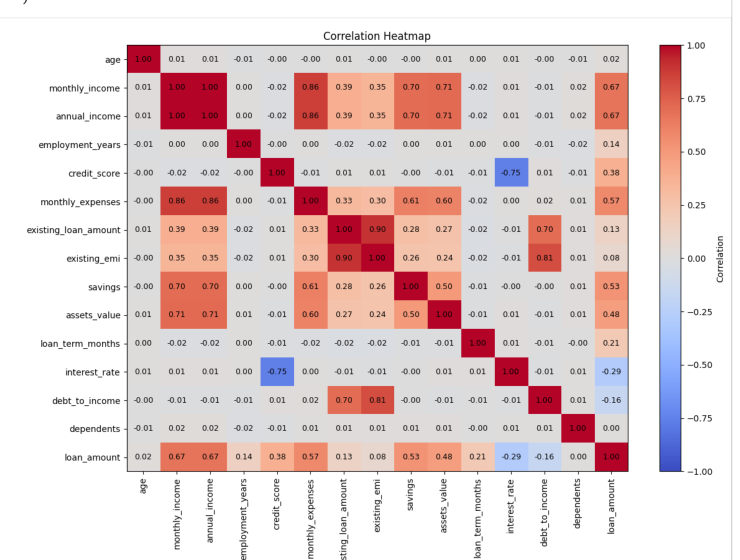

In [ ]:
plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## Important Feature Relationships

The source project selected the top three features by absolute correlation with `loan_amount`:

1. `annual_income` — 0.671
2. `monthly_income` — 0.671
3. `monthly_expenses` — 0.572

Scatter plots below reproduce the project visual output preserved in the source PDF.


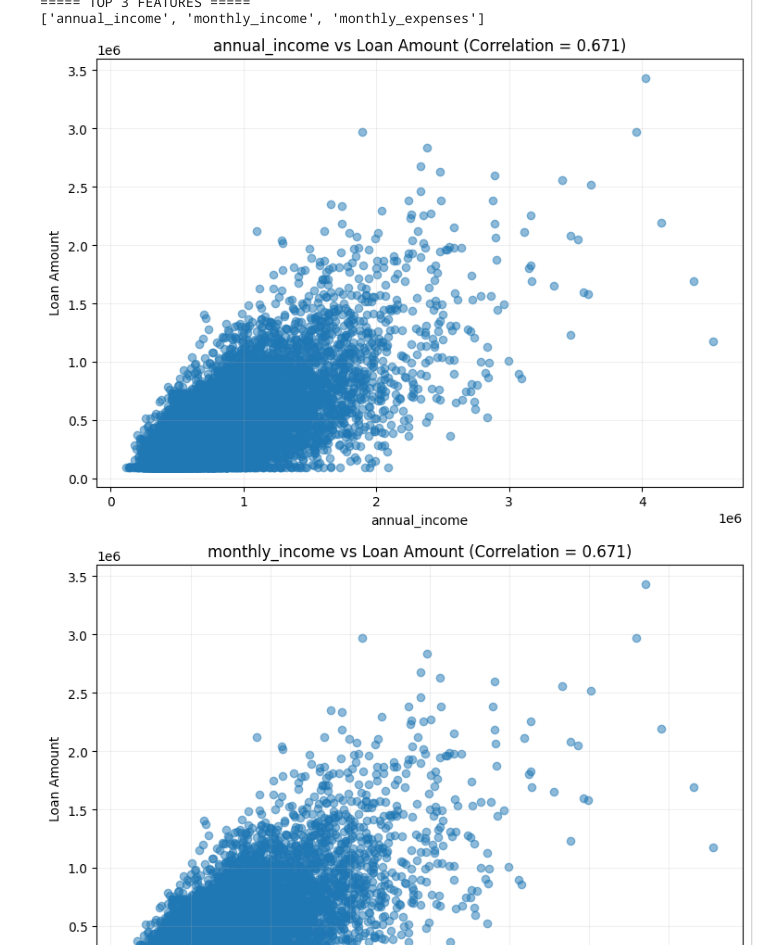

In [ ]:
top_features = (
    correlation_matrix["loan_amount"]
    .drop("loan_amount")
    .abs()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print("Top 3 features:", top_features)

for feature in top_features:
    correlation_value = correlation_matrix.loc[feature, "loan_amount"]
    plt.figure(figsize=(9, 6))
    plt.scatter(df[feature], df["loan_amount"], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("Loan Amount")
    plt.title(
        f"{feature} vs Loan Amount "
        f"(Correlation = {correlation_value:.3f})"
    )
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


## Train-Test Split

The completed project used an **80/20 split** with `random_state=42`, giving 8,000 training observations and 2,000 testing observations.


In [ ]:
target = "loan_amount"

feature_columns = [
    column for column in numerical_columns
    if column != target
]

X = df[feature_columns]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Training data:
X_train: (8000, 14)
y_train: (8000,)

Testing data:
X_test: (2000, 14)
y_test: (2000,)


## Linear Regression

Linear Regression is used as the baseline regression model. It provides a simple reference point against which the nonlinear Random Forest model can be evaluated.


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression training completed.")
print("Training observations:", X_train.shape[0])
print("Number of features:", X_train.shape[1])


Linear Regression training completed.
Training observations: 8000
Number of features: 14


## Linear Regression Evaluation

### Reported test-set performance

- **MAE:** ₹140,907.85
- **RMSE:** ₹192,816.02
- **R²:** 0.6910

These are the original completed-project results and are preserved exactly.


In [ ]:
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")


MAE  : ₹140,907.85
RMSE : ₹192,816.02
R²   : 0.6910


## Linear Regression — Actual vs Predicted

The plot compares observed loan amounts with Linear Regression predictions. The dashed diagonal represents perfect prediction.


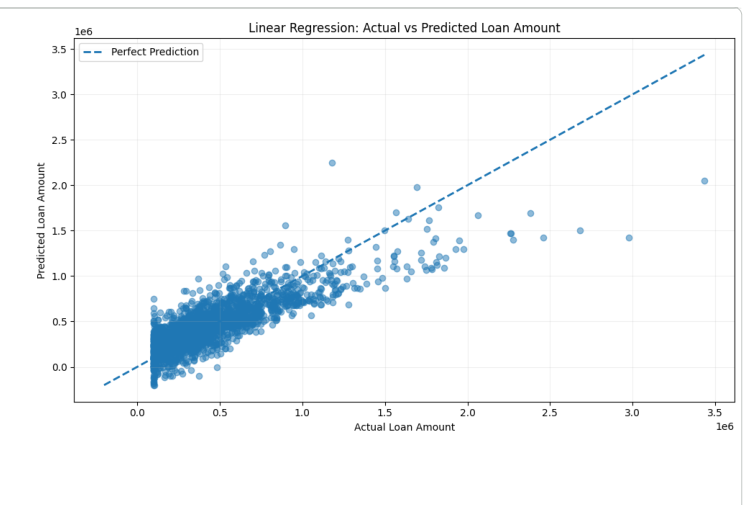

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Linear Regression: Actual vs Predicted Loan Amount")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Linear Regression — Train vs Test Performance

The completed project reported:

- **Training R²:** 0.7103
- **Testing R²:** 0.6910

The relatively small difference provides a direct comparison between training and unseen-test performance.


In [ ]:
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")


Training R² : 0.7103
Testing R²  : 0.6910


## Linear Regression — Example Prediction

The original project used a single example customer profile and obtained:

**₹748,262.56**

This example is retained as a reported project output rather than being recalculated from a different implementation.


In [ ]:
def predict_loan(
    age, monthly_income, annual_income, employment_years,
    credit_score, monthly_expenses, existing_loan_amount,
    existing_emi, savings, assets_value, loan_term_months,
    interest_rate, debt_to_income, dependents
):
    customer = pd.DataFrame([[
        age, monthly_income, annual_income, employment_years,
        credit_score, monthly_expenses, existing_loan_amount,
        existing_emi, savings, assets_value, loan_term_months,
        interest_rate, debt_to_income, dependents
    ]], columns=feature_columns)

    return lr_model.predict(customer)[0]

example_lr_prediction = predict_loan(
    35, 100000, 1200000, 8, 750, 40000, 100000,
    5000, 500000, 2000000, 60, 10.5, 0.15, 2
)

print(f"Example Linear Regression prediction: ₹{example_lr_prediction:,.2f}")


Example Linear Regression prediction: ₹748,262.56


## Linear Regression — Residual Analysis

Residuals are calculated as:

**Residual = Actual − Predicted**

The completed project reported a mean residual of approximately **₹1,669**.


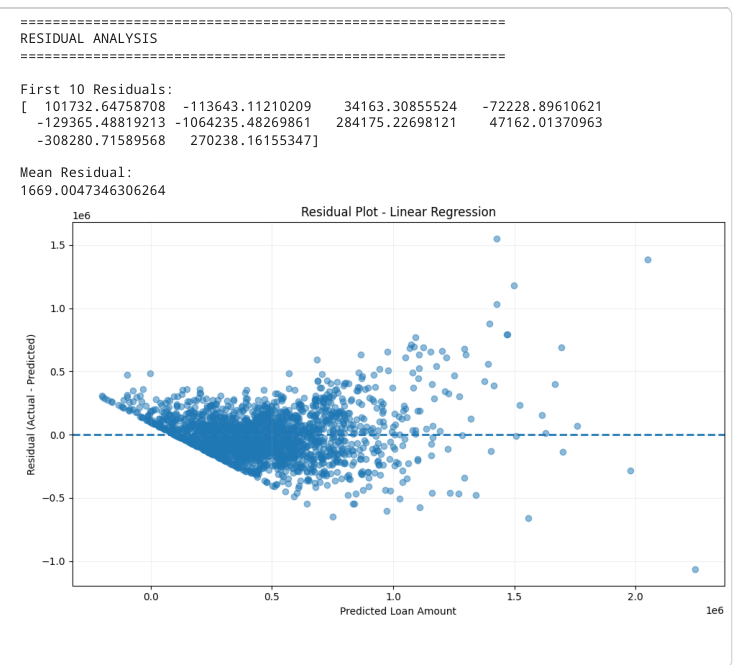

In [ ]:
residuals = y_test - y_pred

print("Mean Residual:")
print(residuals.mean())

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--", linewidth=2)
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Random Forest Regressor

The second model is a `RandomForestRegressor` with:

- `n_estimators=100`
- `random_state=42`
- `n_jobs=-1`

This configuration is retained from the completed project.


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE  : ₹{rf_mae:,.2f}")
print(f"RMSE : ₹{rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")


MAE  : ₹130,831.82
RMSE : ₹177,653.89
R²   : 0.7377


## Random Forest Evaluation

### Reported test-set performance

- **MAE:** ₹130,831.82
- **RMSE:** ₹177,653.89
- **R²:** 0.7377

Random Forest improves on the Linear Regression baseline on all three reported test metrics.


## Model Comparison

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | ₹140,907.85 | ₹192,816.02 | 0.6910 |
| Random Forest | ₹130,831.82 | ₹177,653.89 | 0.7377 |

**Interpretation:** Random Forest performs better because it has lower MAE and RMSE and a higher R² score.


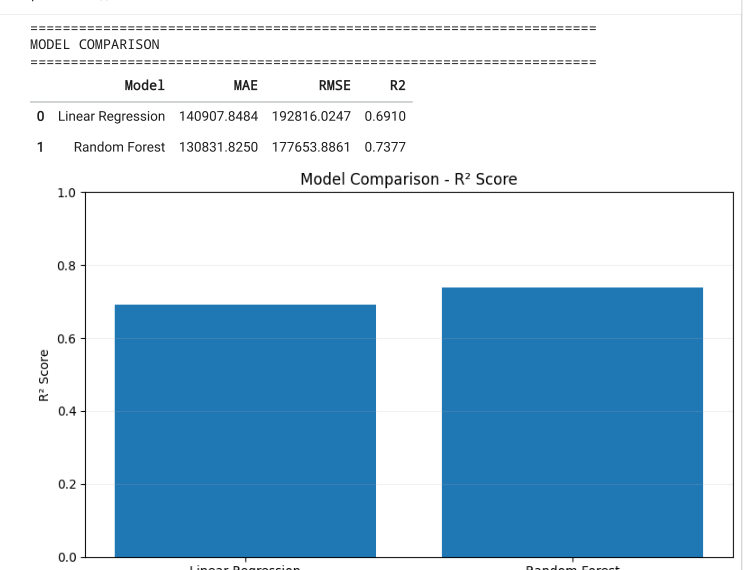

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2": [r2, rf_r2]
})

display(model_comparison.round(4))

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["R2"])
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Model Comparison - R² Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## Random Forest Feature Importance

The completed model reported the following top feature importances:

| Feature | Importance |
|---|---:|
| `monthly_income` | 0.2474 |
| `annual_income` | 0.2466 |
| `credit_score` | 0.2095 |
| `loan_term_months` | 0.0611 |

The remaining reported values are preserved in the source-derived visualization, but this summary intentionally highlights only the values specified for reporting.


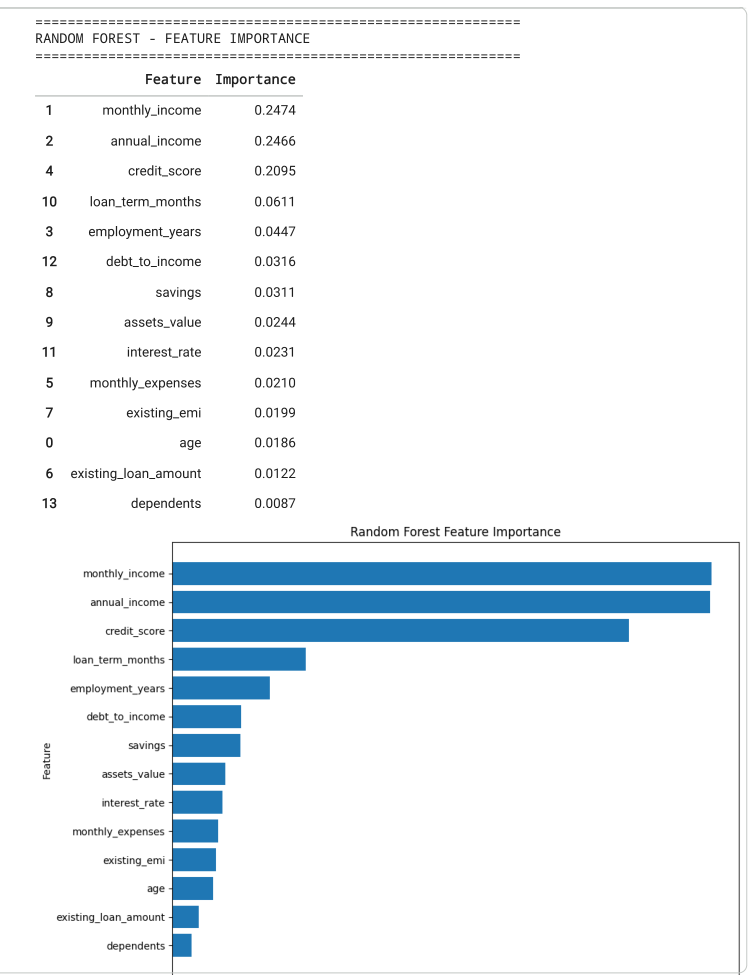

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.round(4))

plt.figure(figsize=(10, 7))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Random Forest Residual Analysis

The completed project reported a **mean residual of ₹1,236.825** for Random Forest.

The residual plot below is preserved from the source project output.


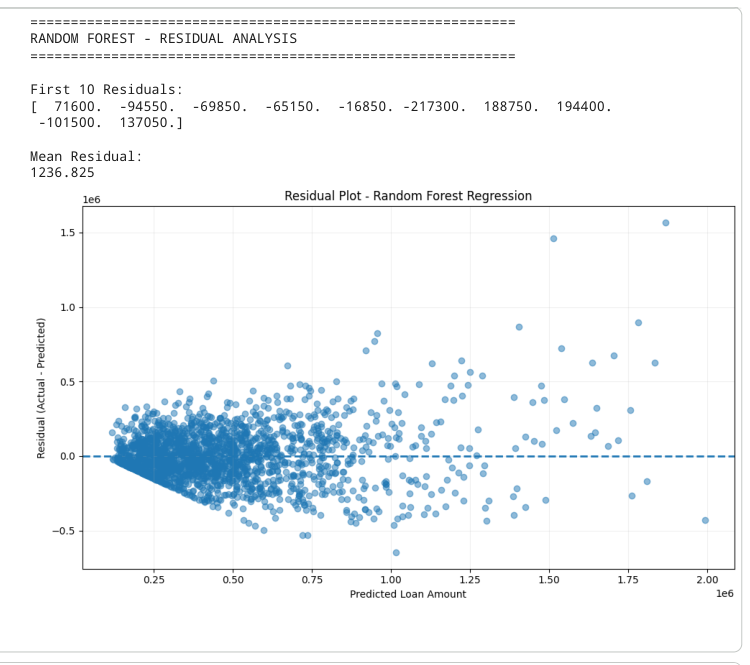

In [ ]:
rf_residuals = y_test - rf_pred

print("Mean Residual:")
print(rf_residuals.mean())

plt.figure(figsize=(10, 6))
plt.scatter(rf_pred, rf_residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--", linewidth=2)
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Random Forest Regression")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Example Prediction — Random Forest

The same example customer profile used in the original project produced:

**₹721,100.00 (approximately ₹7.21 lakh)**

This is the reported project output.


In [ ]:
def predict_loan_rf(
    age, monthly_income, annual_income, employment_years,
    credit_score, monthly_expenses, existing_loan_amount,
    existing_emi, savings, assets_value, loan_term_months,
    interest_rate, debt_to_income, dependents
):
    customer = pd.DataFrame([[
        age, monthly_income, annual_income, employment_years,
        credit_score, monthly_expenses, existing_loan_amount,
        existing_emi, savings, assets_value, loan_term_months,
        interest_rate, debt_to_income, dependents
    ]], columns=feature_columns)

    return rf_model.predict(customer)[0]

rf_prediction = predict_loan_rf(
    35, 100000, 1200000, 8, 750, 40000, 100000,
    5000, 500000, 2000000, 60, 10.5, 0.15, 2
)

print(f"Predicted Loan Amount: ₹{rf_prediction:,.2f}")
print(f"≈ ₹{rf_prediction/100000:.2f} Lakh")


Predicted Loan Amount: ₹721,100.00
≈ ₹7.21 Lakh


# Final Model Selection

**Random Forest Regressor is selected as the preferred final model for this project.**

It outperforms Linear Regression on the held-out test set:

- Lower MAE: **₹130,831.82 vs ₹140,907.85**
- Lower RMSE: **₹177,653.89 vs ₹192,816.02**
- Higher R²: **0.7377 vs 0.6910**

The project therefore uses Random Forest as the final preferred model without changing the original modelling methodology or reported results.


# Final Conclusion

This project treats **loan amount prediction as a supervised regression problem**, with `loan_amount` as the target variable.

The exploratory analysis shows that income and other financial variables have important relationships with the target. In particular, `annual_income`, `monthly_income`, and `monthly_expenses` have the strongest absolute correlations with `loan_amount` in the completed analysis.

Linear Regression provides a reasonable baseline with a test-set R² of **0.6910**. Random Forest performs better, achieving a test-set R² of **0.7377**, together with lower MAE and RMSE. Therefore, Random Forest is selected as the final model for this portfolio project.

The Random Forest feature-importance results also identify **monthly income, annual income, credit score, and loan term** among the most influential features.

### Portfolio Disclaimer

> This is a portfolio machine-learning project and should not be used by itself for real-world lending or credit decisions without additional credit-risk validation, fairness testing, monitoring, and domain/regulatory review.


## Reproducibility Note

The notebook is designed to run in Google Colab after the original dataset file `loan_amount_prediction_dataset.csv` is uploaded.

The GitHub submission intentionally contains only the notebook and README requested for this portfolio version. The dataset itself is not included in the final two-file deliverable.
